# Zadanie 2: optymalizacja z ograniczeniami

Termin realizacji: 30 marca 2026

Wybierz funkcję testową wykorzystaną w zadaniu 1.

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Dodaj ograniczenie postaci $x_1^2 + x_2 + b = 0$ ze stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia.
2. Zaimplementuj metodę funkcji kary do rozwiązania tego problemu. Zwróć uwagę, aby metoda wykonywała częściową optymalizację dla każdej wielkości parametru kary $\mu_k$ (wykonanie od 1 do 5 kroków dla ustalonej wartości parametru kary -- do samodzielnego wyboru).
3. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
4. Wykorzystaj ponownie metodę optymalizacji z poprzedniego projektu. Jako funkcję celu i jej gradient przekaż funkcje uwzględniające karę (ogólny schemat):
```
function penalty_gradient_descent(f, f_grad, x0; ...)
    x_k = copy(x0)
    for i in 1:max_iter
        # dodać: wyliczanie współczynnika kary
        function penalized_f(x)
            # do uzupełnienia
        end
        function penalized_f_grad(x)
            # do uzupełnienia
        end
        x_k = gradient_descent(penalized_f, penalized_f_grad, x_k; max_iter=3)
    end
end
```
5. Przeprowadź procedurę dla kilkunastu kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień metodę największego spadku na metodę gradientów sprzężonych. Metoda ta powinna wykorzystywać przeszukiwanie w kierunku uwzględniające regułę Armijo.
3. Wraz ze zwiększaniem się parametru kary powinna maleć norma gradientu przy której kończymy działanie metody gradientów sprzężonych, na przykład może być równa $10^{-2} / \mu_k$. 

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Wykonaj benchmarking metody z użyciem `BenchmarkTools.jl`. Zanotuj czasy działania wywołań optymalizacji oraz liczbę alokacji. Spróbuj zoptymalizować działanie funkcji korzystając wymienionych tu rad: [Julia performance tips](https://docs.julialang.org/en/v1/manual/performance-tips/). W sprawozdaniu napisz jakie zmiany wykonane i jak wpłynęły na czas działania programu.

Uwagi:

1. Dodanie typów w nagłówku metody przyspiesza kod tylko w rzadkich i bardzo szczególnych sytuacjach, i to tylko dla typów reprezentujących typy (`Core.Type`) lub funkcje.
2. Dobrym pomysłem jest wykonywanie operacji na tablicach w miejscu i unikanie alokacji. Warto też zwrócić uwagę na tzw. _type stability_, czyli unikanie sytuacji w których typ zmiennej zależy od wartości innej zmiennej.


In [1]:
import Pkg
#Pkg.add(["Plots", "ForwardDiff"])
using LinearAlgebra, Plots, Random, ForwardDiff;

In [2]:
function three_hump_camel(x::AbstractVector)::Real
    return 2*x[1]^2 - 1.05*x[1]^4 + x[1]^6/6 + x[1]*x[2] + x[2]^2
end

function grad_three_hump_camel(x::AbstractVector)::Vector{Float64}
    return ForwardDiff.gradient(three_hump_camel, x)    
end

three_hump_domain = [-5.0, 5.0];

# Na 3.0

In [3]:
# Punkt 1: ograniczenie x1^2 + x2 + b = 0
# Dla Three Hump Camel minimum globalne jest w (0, 0), więc wybieramy b = 1.0,
# wtedy 0^2 + 0 + 1.0 = 1.0 != 0 i minimum nie spełnia ograniczenia.

const b_constraint = 1.0

constraint(x::AbstractVector, b::Float64=b_constraint) = x[1]^2 + x[2] + b
constraint_grad(x::AbstractVector) = [2.0 * x[1], 1.0]

x_min_thc = [0.0, 0.0]
println("Sprawdzenie ograniczenia w minimum Three Hump Camel: g([0,0]) = ", constraint(x_min_thc));

Sprawdzenie ograniczenia w minimum Three Hump Camel: g([0,0]) = 1.0


In [4]:
# Punkt 2: metoda funkcji kary z częściową optymalizacją dla każdego mu_k

function gradient_descent(f, f_grad, x0::AbstractVector; alpha::Float64=1e-3, max_iter::Int=100)
    x = copy(x0)
    x_hist = Vector{Vector{Float64}}()
    f_hist = Float64[]

    fx0 = f(x)
    if !isfinite(fx0)
        return x, f_hist, x_hist
    end

    push!(x_hist, copy(x))
    push!(f_hist, fx0)

    for _ in 1:max_iter
        g = f_grad(x)
        if !all(isfinite, g)
            break
        end

        x_new = x .- alpha .* g
        if !all(isfinite, x_new)
            break
        end

        fx_new = f(x_new)
        if !isfinite(fx_new)
            break
        end

        x = x_new
        push!(x_hist, copy(x))
        push!(f_hist, fx_new)
    end

    return x, f_hist, x_hist
end

function penalty_gradient_descent(f, f_grad, x0::AbstractVector;
    b::Float64=b_constraint,
    mu0::Float64=1.0,
    rho::Float64=1.5,
    outer_iter::Int=25,
    inner_steps::Int=4,
    alpha::Float64=1e-3)

    x = copy(x0)

    penalized_hist = Float64[]
    original_hist = Float64[]
    constraint_hist = Float64[]
    mu_hist = Float64[]

    # Stan początkowy
    first_mu = mu0
    g0 = constraint(x, b)
    p0 = f(x) + 0.5 * first_mu * g0^2
    if !isfinite(p0)
        return x, penalized_hist, original_hist, constraint_hist, mu_hist
    end

    push!(penalized_hist, p0)
    push!(original_hist, f(x))
    push!(constraint_hist, abs(g0))
    push!(mu_hist, first_mu)

    for k in 1:outer_iter
        mu_k = min(mu0 * rho^(k - 1), 1.0e6)

        # Definiuj funkcje z karą dla tego kroku
        local penalized_f, penalized_f_grad
        
        penalized_f = (xv) -> begin
            fval = f(xv)
            gval = constraint(xv, b)
            fval + 0.5 * mu_k * gval^2
        end

        penalized_f_grad = (xv) -> begin
            f_grad(xv) .+ mu_k * constraint(xv, b) .* constraint_grad(xv)
        end

        x_new, p_hist, x_hist = gradient_descent(
            penalized_f, penalized_f_grad, x;
            alpha=alpha, max_iter=inner_steps
        )

        if isempty(p_hist)
            break
        end

        # Dopisujemy historię krok po kroku (pomijamy punkt startowy segmentu)
        for j in 2:length(p_hist)
            xv = x_hist[j]
            push!(penalized_hist, p_hist[j])
            push!(original_hist, f(xv))
            push!(constraint_hist, abs(constraint(xv, b)))
            push!(mu_hist, mu_k)
        end

        x = x_new
    end

    return x, penalized_hist, original_hist, constraint_hist, mu_hist
end;

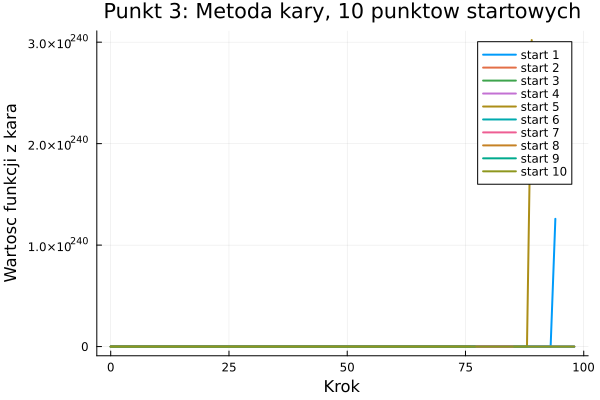

In [5]:
# Punkt 3: 10 losowych punktów, 100 kroków, wykres wartości funkcji od kroku

rand_uniform(a, b) = rand() * (b - a) + a

function run_penalty_experiments(f, f_grad, domain::AbstractVector{<:Real};
    n_points::Int=10,
    total_steps::Int=100,
    inner_steps::Int=4,
    alpha::Float64=5e-4,
    b::Float64=b_constraint,
    mu0::Float64=1.0,
    rho::Float64=1.5,
    seed::Int=42)

    Random.seed!(seed)

    outer_iter = cld(total_steps, inner_steps)
    starts = [[rand_uniform(domain[1], domain[2]), rand_uniform(domain[1], domain[2])] for _ in 1:n_points]

    histories_pen = Vector{Vector{Float64}}()
    histories_orig = Vector{Vector{Float64}}()
    histories_constr = Vector{Vector{Float64}}()

    for x0 in starts
        _, h_pen, h_orig, h_constr, _ = penalty_gradient_descent(
            f, f_grad, x0;
            b=b, mu0=mu0, rho=rho,
            outer_iter=outer_iter, inner_steps=inner_steps, alpha=alpha
        )
        if !isempty(h_pen)
            push!(histories_pen, h_pen[1:min(end, total_steps + 1)])
            push!(histories_orig, h_orig[1:min(end, total_steps + 1)])
            push!(histories_constr, h_constr[1:min(end, total_steps + 1)])
        end
    end

    return starts, histories_pen, histories_orig, histories_constr
end

starts, histories_pen, histories_orig, histories_constr = run_penalty_experiments(
    three_hump_camel, grad_three_hump_camel, three_hump_domain;
    n_points=10, total_steps=100, inner_steps=4,
    alpha=0.0005, b=b_constraint, mu0=1.0, rho=1.5, seed=42
)

p = plot(
    title="Punkt 3: Metoda kary, 10 punktow startowych",
    xlabel="Krok",
    ylabel="Wartosc funkcji z kara",
    legend=:topright
)

for i in 1:length(histories_pen)
    plot!(p, 0:length(histories_pen[i]) - 1, histories_pen[i], label="start $i", lw=2)
end

display(p);

In [6]:
# Punkt 4: jawne przekazanie penalized_f i penalized_f_grad do gradient_descent

x0_demo = [2.5, -3.0]
mu_demo = 10.0

penalized_f_demo(x) = three_hump_camel(x) + 0.5 * mu_demo * constraint(x, b_constraint)^2
penalized_f_grad_demo(x) = grad_three_hump_camel(x) .+ mu_demo * constraint(x, b_constraint) .* constraint_grad(x)

x_after, hist_after, _ = gradient_descent(
    penalized_f_demo,
    penalized_f_grad_demo,
    x0_demo;
    alpha=0.001,
    max_iter=3
)

println("Punkt 4: przykład 3 kroków gradient_descent na funkcji z karą")
println("x0 = ", x0_demo)
println("x_po_3_krokach = ", x_after)
println("historia P(x) = ", hist_after);

Punkt 4: przykład 3 kroków gradient_descent na funkcji z karą
x0 = [2.5, -3.0]
x_po_3_krokach = [1.9921469694578735, -3.0846293336646644]
historia P(x) = [103.98697916666666, 52.7124490455571, 32.838030714732184, 22.934998501933343]


In [7]:
# Punkt 5: ilustracja powolnej, szybkiej i braku zbieżności - rysuj f(x) i |g(x)|

using Statistics

function convergence_analysis(f, f_grad, domain::AbstractVector{<:Real};
    n_points::Int=10,
    total_steps::Int=30,
    inner_steps::Int=3,
    alpha::Float64=1e-3,
    mu0::Float64=1.0,
    rho::Float64=2.0,
    seed::Int=7)

    _, _, histories_f, histories_g = run_penalty_experiments(
        f, f_grad, domain;
        n_points=n_points,
        total_steps=total_steps,
        inner_steps=inner_steps,
        alpha=alpha,
        b=b_constraint,
        mu0=mu0,
        rho=rho,
        seed=seed
    )

    histories_f_nonempty = [h for h in histories_f if !isempty(h)]
    histories_g_nonempty = [h for h in histories_g if !isempty(h)]
    
    if isempty(histories_f_nonempty) || isempty(histories_g_nonempty)
        return [NaN], [NaN]
    end

    n = minimum(length.(histories_f_nonempty))
    avg_f = [mean([histories_f_nonempty[i][k] for i in 1:length(histories_f_nonempty)]) for k in 1:n]
    avg_g = [mean([histories_g_nonempty[i][k] for i in 1:length(histories_g_nonempty)]) for k in 1:n]
    
    return avg_f, avg_g
end

configs = [
    ("Powolna zbieznosc", 0.00005, 1.3),
    ("Szybka zbieznosc",  0.00050, 1.5),
    ("Brak zbieznosci",   0.02000, 2.0)
]

plots_f = Any[]
plots_g = Any[]

for (name, alpha, rho) in configs
    avg_f, avg_g = convergence_analysis(
        three_hump_camel, grad_three_hump_camel, three_hump_domain;
        n_points=10, total_steps=50, inner_steps=3,
        alpha=alpha, mu0=1.0, rho=rho, seed=7
    )

    # Wykres f(x)
    p_f = plot(
        0:length(avg_f)-1,
        avg_f,
        lw=3,
        label="f(x)",
        title=name,
        xlabel="Krok",
        ylabel="f(x)",
        legend=:topright
    )
    push!(plots_f, p_f)

    # Wykres |g(x)|
    p_g = plot(
        0:length(avg_g)-1,
        avg_g,
        lw=3,
        label="|g(x)|",
        title=name,
        xlabel="Krok",
        ylabel="|g(x)|",
        legend=:topright,
        yscale=:log10
    )
    push!(plots_g, p_g)
end

# Łącz wykresy: f(x) w górnym wierszu, |g(x)| w dolnym
combined = [plots_f[1], plots_f[2], plots_f[3],
            plots_g[1], plots_g[2], plots_g[3]]
plot(combined..., layout=(2, 3), size=(1400, 800));

# Na 4.0

In [8]:
function armijo_line_search(f::Function, f_grad::Function, x::AbstractVector, d::AbstractVector, g::AbstractVector; 
                            alpha_init::Float64=1.0, c::Float64=1e-4, tau::Float64=0.5, max_iter::Int=20)
    alpha = alpha_init
    fx = f(x)
    
    m = dot(g, d)
    
    if m >= 0
        return 1e-4
    end
    
    for _ in 1:max_iter
        x_new = x .+ alpha .* d
        if f(x_new) <= fx + c * alpha * m
            return alpha
        end
        alpha *= tau
    end
    
    return alpha
end;

In [9]:
function conjugate_gradient(f::Function, f_grad::Function, x0::AbstractVector; 
                            tol::Float64=1e-5, max_iter::Int=100)
    x = copy(x0)
    x_hist = Vector{Vector{Float64}}()
    f_hist = Float64[]

    push!(x_hist, copy(x))
    push!(f_hist, f(x))

    g = f_grad(x)
    d = -g
    
    for i in 1:max_iter
        if norm(g) <= tol
            break
        end

        alpha = armijo_line_search(f, f_grad, x, d, g)
        
        x_new = x .+ alpha .* d
        g_new = f_grad(x_new)
        
        beta = max(0.0, dot(g_new, g_new .- g) / (dot(g, g) + 1e-12))
        
        d_new = -g_new .+ beta .* d
        
        if dot(d_new, g_new) >= 0
            d_new = -g_new
        end
        
        x = x_new
        g = g_new
        d = d_new
        
        push!(x_hist, copy(x))
        push!(f_hist, f(x))
    end

    return x, f_hist, x_hist
end;

In [10]:
# Na 4.0: Funkcja optymalizacji metodą kary wywołująca gradienty sprzężone
function penalty_cg_method(f::Function, f_grad::Function, x0::AbstractVector;
                           b::Float64=b_constraint, mu0::Float64=1.0, rho::Float64=1.5, 
                           outer_iter::Int=25, max_inner_steps::Int=50)
    x = copy(x0)

    penalized_hist = Float64[]
    mu_hist = Float64[]

    first_mu = mu0
    push!(penalized_hist, f(x) + 0.5 * first_mu * constraint(x, b)^2)
    push!(mu_hist, first_mu)

    for k in 1:outer_iter
        mu_k = min(mu0 * rho^(k - 1), 1.0e6)
        
        # Na 4.0: Malejąca norma gradientu, przy której kończymy metodę (1 / mu)
        tol_k = 1.0 / mu_k

        # Lokalne funkcje celu i gradientu z uwzględnieniem kary
        penalized_f(xv) = f(xv) + 0.5 * mu_k * constraint(xv, b)^2
        penalized_f_grad(xv) = f_grad(xv) .+ mu_k * constraint(xv, b) .* constraint_grad(xv)

        # Wywołanie gradientów sprzężonych zamiast największego spadku
        x_new, p_hist, _ = conjugate_gradient(
            penalized_f, penalized_f_grad, x;
            tol=tol_k, max_iter=max_inner_steps
        )

        for j in 2:length(p_hist)
            push!(penalized_hist, p_hist[j])
            push!(mu_hist, mu_k)
        end

        x = x_new
    end

    return x, penalized_hist, mu_hist
end;

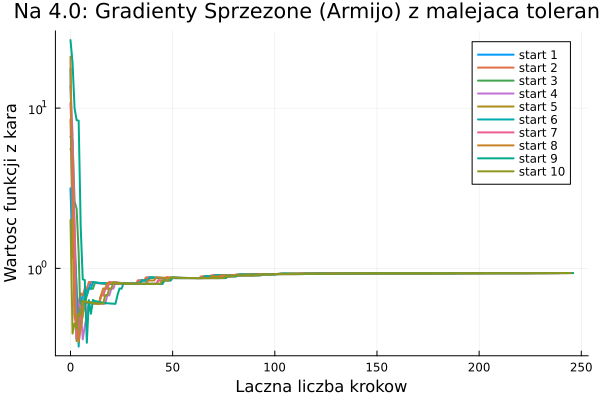

In [11]:
# Na 4.0: Eksperyment dla 10 punktów (możemy użyć zmiennej `starts` z punktu na 3.0)

p_cg = plot(
    title="Na 4.0: Gradienty Sprzezone (Armijo) z malejaca tolerancja",
    xlabel="Laczna liczba krokow",
    ylabel="Wartosc funkcji z kara",
    legend=:topright,
    yscale=:log10 # Skala logarytmiczna ładnie uwidacznia momenty ostrego spadku
)

# Tablica starts pochodzi z wywołania funkcji na 3.0
for (i, x0) in enumerate(starts)
    x_opt, p_hist, _ = penalty_cg_method(
        three_hump_camel, grad_three_hump_camel, x0;
        b=b_constraint, mu0=1.0, rho=1.5, outer_iter=20, max_inner_steps=100
    )
    plot!(p_cg, 0:length(p_hist)-1, p_hist, label="start $i", lw=2)
end

display(p_cg);

# Na 5.0

In [12]:
# using Pkg
# Pkg.add("BenchmarkTools");

### Najpierw przeprowadziliśmy benchmarking obecnego rozwiązania z gradientami sprzeżonymi 

In [50]:
using BenchmarkTools
res = @benchmark for x0 in $starts
    penalty_cg_method(
        $three_hump_camel, 
        $grad_three_hump_camel, 
        x0;
        b=$b_constraint, 
        mu0=1.0, 
        rho=1.5, 
        outer_iter=20, 
        max_inner_steps=100
    )
end;
show(stdout, MIME("text/plain"), res);

BenchmarkTools.Trial: 1631 samples with 1 evaluation per sample.
 Range (min … max):  2.286 ms … 62.646 ms  ┊ GC (min … max):  0.00% … 94.59%
 Time  (median):     2.368 ms              ┊ GC (median):     0.00%
 Time  (mean ± σ):   3.061 ms ±  3.042 ms  ┊ GC (mean ± σ):  14.89% ± 14.33%

  █▂ ▁  ▄▁                                                    
  ████████▇▆▁▅▃▃▃▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▅▇▄▆▆ █
  2.29 ms      Histogram: log(frequency) by time     15.4 ms <

 Memory estimate: 3.73 MiB, allocs estimate: 90644.

In [14]:
function armijo_line_search_opt!(f,x,d,g,x_buffer;alpha_init=1.0, c=1e-4, tau = 0.5, max_iter=20)
    alpha = alpha_init
    fx = f(x)
    m = dot(g,d)
    if m >= 0
        return 1e-4
    end
    
    c_m = c * m
    for _ in 1:max_iter
        x_buffer .= x .+ alpha .* d
        if f(x_buffer) <= fx + alpha * c_m
            return alpha
        end
        alpha *= tau
    end
    return alpha  
end;

### Potem przeprowadziliśmy optymalizacje dla armijo search i udało nam się zredukować liczbę alokacji do zera

In [15]:
x_test = [1.0, 1.0]
g_test = grad_three_hump_camel(x_test)
d_test = -g_test             
x_buf  = similar(x_test)
@btime armijo_line_search($three_hump_camel,grad_three_hump_camel ,$x_test, $d_test, $g_test)
@btime armijo_line_search_opt!($three_hump_camel, $x_test, $d_test, $g_test, $x_buf);


  86.931 ns (4 allocations: 160 bytes)
  57.456 ns (0 allocations: 0 bytes)


### Potem zoptymalizowaliśmy funkcję gradientową, żeby nie alokowała pamięci

In [16]:
cfg = ForwardDiff.GradientConfig(three_hump_camel, zeros(2))
function grad_three_hump_camel_opt!(storage,x,config)
    ForwardDiff.gradient!(storage,three_hump_camel,x,config)
    return nothing
end;

In [17]:
x = [1.0, 1.0]
storage = [0.0, 0.0]

@btime grad_three_hump_camel($x)
@btime grad_three_hump_camel_opt!($storage,$x,$cfg);

  342.280 ns (5 allocations: 240 bytes)
  35.866 ns (0 allocations: 0 bytes)


### Potem zoptymalizowaliśmy gradienty sprzężone, pozostawiając tylko jedną alokację

In [18]:
function conjugate_gradient_opt!(f::Function,f_grad!, x::AbstractVector,
    x_buffer::AbstractVector, g::AbstractVector, g_old::AbstractVector, d::AbstractVector,cfg;
    tol::Float64=1e-5, max_iter::Int=100, store_history=true)

    if store_history
        x_hist = [copy(x)]
        f_hist = [f(x)]
    end

    f_grad!(g,x,cfg)
    d .= .-g
    
    for i in 1:max_iter
        gnorm = norm(g)
        if gnorm <= tol
            break
        end

        alpha = armijo_line_search_opt!(f,x,d,g,x_buffer)
        x .+= alpha .* d
        g_old .= g
        f_grad!(g,x,cfg)

        num = dot(g,g) - dot(g,g_old)
        den = dot(g_old,g_old) + 1e-12
        beta = max(0.0,num/den)
        d .= .-g .+ beta .* d

        if dot(d,g) >= 0
            d .= .-g
        end
        if store_history
            push!(x_hist, copy(x))
            push!(f_hist, f(x))
        end
    end
    if store_history
        return x, f_hist, x_hist
    else
        return x, nothing, nothing
    end
end;


In [19]:
methods(conjugate_gradient_opt!);

In [21]:
x_start = [1.0, 1.0]


x_work = copy(x_start)
xb = similar(x_start)
g  = similar(x_start)
go = similar(x_start)
d  = similar(x_start)

x_work .= x_start

res_x, f_hist, x_hist = conjugate_gradient_opt!(
    three_hump_camel, grad_three_hump_camel_opt!,
    x_work, xb, g, go, d,cfg;
    max_iter=50, store_history=true
)

println("Wynik optymalizacji: ", res_x)
println("Liczba iteracji: ", length(f_hist))
println("Wartość funkcji w minimum: ", three_hump_camel(res_x));

Wynik optymalizacji: [-5.336291901165819e-7, 6.554093904458986e-7]
Liczba iteracji: 15
Wartość funkcji w minimum: 6.493361119550899e-13


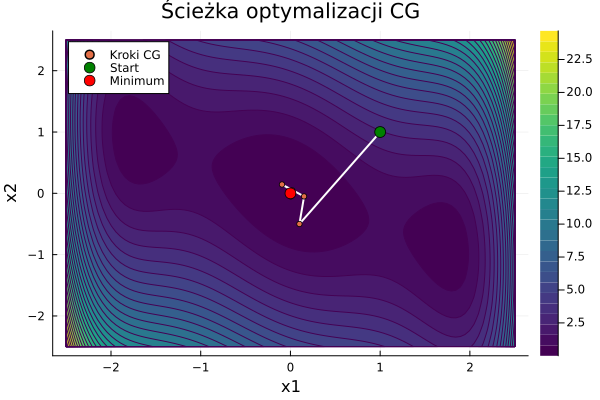

In [22]:
path_x = [pt[1] for pt in x_hist]
path_y = [pt[2] for pt in x_hist]
x_rng = range(-2.5, 2.5, length=100)
y_rng = range(-2.5, 2.5, length=100)


z = [three_hump_camel([xi, yi]) for xi in x_rng, yi in y_rng]


p1 = contour(x_rng, y_rng, z', 
    levels=30, 
    fill=true, 
    c=:viridis, 
    title="Ścieżka optymalizacji CG",
    xlabel="x1", ylabel="x2")


plot!(p1, path_x, path_y, 
    lc=:white,     
    lw=2,          
    marker=:circle, 
    ms=3,          
    label="Kroki CG")

scatter!(p1, [path_x[1]], [path_y[1]], color=:green, label="Start", markersize=6)
scatter!(p1, [path_x[end]], [path_y[end]], color=:red, label="Minimum", markersize=6)

display(p1);

In [23]:
println("\nBenchmark (bez historii):")
@btime conjugate_gradient_opt!(
    $three_hump_camel, 
    $grad_three_hump_camel_opt!, 
    x_tmp, $xb, $g, $go, $d,$cfg; 
    max_iter=50, store_history=false
) setup=(x_tmp = copy($x_start));


Benchmark (bez historii):
  65.995 ns (1 allocation: 16 bytes)


### Kolejnym krokiem była optymalizacja całej pętli optymalizacji z ograniczeniami

In [24]:
function constraint_grad_opt!(storage,x)
    storage[1] = 2.0 * x[1]
    storage[2] = 1.0
    return nothing
end;

In [25]:
function penalty_cg_method_opt(f,f_grad!,constraint,constraint_grad_opt!,x0,cfg;
    b=4.0,mu0=1.0,rho=1.5,outer_iter=25,max_inner_steps=50,store_history=true)
    x=copy(x0)
    xb = similar(x)
    g = similar(x)
    go = similar(x)
    d = similar(x)
    gc = similar(x)

    penalized_f_hist = Float64[]
    mu_history = Float64[]

    for k in 1:outer_iter
        mu_k = min(mu0 * rho^(k-1),1e8)
        tol_k = 1.0/mu_k
        pf(xv) = f(xv) + 0.5 * mu_k * constraint(xv,b)^2

        function pf_grad!(storage,xv,config)
            f_grad!(storage,xv,config)
            c_val = constraint(xv,b)
            constraint_grad_opt!(gc,xv)
            storage .+= (mu_k * c_val) .* gc
            return nothing
        end

        x, inner_f, _ = conjugate_gradient_opt!(
            pf,pf_grad!, x,xb,g,go,d,cfg;
            tol=tol_k,max_iter=max_inner_steps, store_history=store_history
        )

        if store_history
            append!(penalized_f_hist,inner_f)
            for _ in 1:length(inner_f)
                push!(mu_history,mu_k)
            end
        end
    end
    return x, penalized_f_hist, mu_history
end;

In [26]:
cfg = ForwardDiff.GradientConfig(three_hump_camel, zeros(2))

@btime penalty_cg_method_opt(
    $three_hump_camel, 
    $grad_three_hump_camel_opt!, 
    $constraint, 
    $constraint_grad_opt!, 
    $x_start, 
    $cfg; 
    store_history=false
);

  142.743 μs (39 allocations: 944 bytes)


In [40]:
x_start = [1.0, 1.0]
b_val = 1.0
mu_start = 1.0
rho_val = 2.0


x_opt, f_hist, mu_hist = penalty_cg_method_opt(
    three_hump_camel, 
    grad_three_hump_camel_opt!, 
    constraint, 
    constraint_grad_opt!, 
    x_start, 
    cfg; 
    b=b_val, 
    mu0=mu_start, 
    rho=rho_val, 
    outer_iter=20, 
    store_history=true
);

In [41]:
g_final = constraint(x_opt, b_val)
f_final = three_hump_camel(x_opt)

println("--- TEST JAKOŚCIOWY ---")
println("Punkt startowy: ", x_start)
println("Punkt końcowy (x_opt): ", x_opt)
println("Wartość funkcji celu f(x_opt): ", f_final)
println("Wartość ograniczenia g(x_opt): ", g_final)
println("Ostatnie mu: ", mu_hist[end])

if abs(g_final) < 0.01
    println("Sukces: Ograniczenie jest spełnione (bliskie 0).")
else
    println("Błąd: Algorytm nie zbliżył się do ograniczenia.")
end;

--- TEST JAKOŚCIOWY ---
Punkt startowy: [1.0, 1.0]
Punkt końcowy (x_opt): [0.13154054501852647, -1.0172992851880052]
Wartość funkcji celu f(x_opt): 0.9353740661698178
Wartość ograniczenia g(x_opt): 3.629795765847099e-6
Ostatnie mu: 524288.0
Sukces: Ograniczenie jest spełnione (bliskie 0).


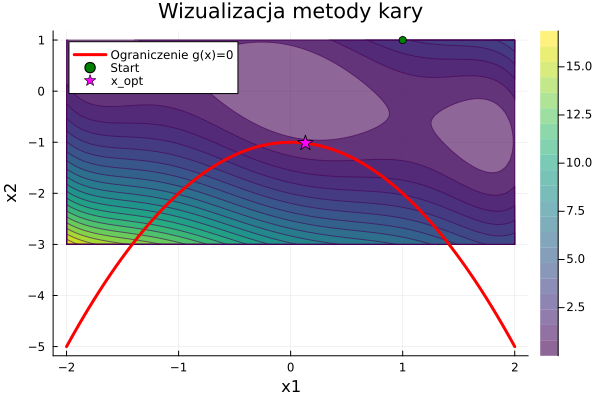

In [43]:
x1_rng = range(-2.0, 2.0, length=100)
x2_rng = range(-3.0, 1.0, length=100)
z = [three_hump_camel([x1, x2]) for x1 in x1_rng, x2 in x2_rng]

p = contour(x1_rng, x2_rng, z', levels=20, fill=true, c=:viridis, alpha=0.6,
            title="Wizualizacja metody kary", xlabel="x1", ylabel="x2")

constraint_line_x2 = [-x1^2 - 1.0 for x1 in x1_rng]
plot!(p, x1_rng, constraint_line_x2, color=:red, lw=3, label="Ograniczenie g(x)=0")

scatter!(p, [x_start[1]], [x_start[2]], color=:green, label="Start")
scatter!(p, [x_opt[1]], [x_opt[2]], color=:magenta, markershape=:star, ms=8, label="x_opt")

display(p)

### Widać trzykrotną redukcję czasu i znaczną redukcję pamięci

Średni czas wychodzi ~800 mikrosekund zamiast 2,9 ms

In [48]:
res = @benchmark for x0 in $starts
    penalty_cg_method_opt(
    $three_hump_camel, 
    $grad_three_hump_camel_opt!, 
    $constraint, 
    $constraint_grad_opt!, 
    $x_start, 
    $cfg; 
    store_history=false,
    outer_iter=20, 
    max_inner_steps=100
    )
end;

In [49]:
pretty_res = replace(sprint(show, MIME("text/plain"), res), "μs" => "us")

println(pretty_res)

BenchmarkTools.Trial: 5851 samples with 1 evaluation per sample.
 Range (min … max):  792.542 us …   2.189 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     805.869 us               ┊ GC (median):    0.00%
 Time  (mean ± σ):   852.657 us ± 172.106 us  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █▄▄▅▁▁                                                         
  ██████▇▇▆▇▆▆▄▄▅▅▄▄▄▄▅▅▄▄▄▂▄▅▄▄▅▄▄▄▅▄▄▅▄▅▄▄▄▄▅▄▄▃▅▄▃▄▄▄▄▂▅▅▄▄▆ █
  793 us        Histogram: log(frequency) by time       1.85 ms <

 Memory estimate: 8.44 KiB, allocs estimate: 340.


### Wnioski z zadania 5:
- Robienie obliczeń w miejscu i usuwanie niepotrzebnych alokacji jest skuteczne w zmniejszaniu czasu wykonania programu